<a href="https://colab.research.google.com/github/prajwoldahal/AI-and-ML/blob/main/2406799_PrajwalDahal_Code_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Task
# Garbage Classification

**Dataset:** Garbage Classification


---

## 0. Setup & Imports

In [1]:
!pip install kagglehub -q

import kagglehub, os, time, warnings
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Download dataset
download_path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

local_path = "/content/garbage_data"
if not os.path.exists(local_path):
    os.symlink(download_path, local_path)

data_dir = "/content/garbage_data/original"
print("Classes found:", sorted(os.listdir(data_dir)))

100%|██████████| 1.07G/1.07G [00:14<00:00, 77.3MB/s]

Extracting files...


Classes found: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


---
## Part A — CNNs from Scratch
---
## 1. Data Understanding, Analysis, Visualization & Cleaning

In [3]:
# 1.1 Class distribution
class_names = sorted(os.listdir(data_dir))
class_counts = {}
total_images = 0

for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[cls] = count
        total_images += count

print(f"Total images  : {total_images}")
print(f"Total classes : {len(class_names)}")
print("\nPer-class count:")
for cls, cnt in class_counts.items():
    print(f"  {cls:<20s} {cnt:>5d}  ({100*cnt/total_images:.1f}%)")

Total images  : 12259
Total classes : 10

Per-class count:
  battery                756  (6.2%)
  biological             699  (5.7%)
  cardboard             1411  (11.5%)
  clothes               1892  (15.4%)
  glass                 1736  (14.2%)
  metal                  930  (7.6%)
  paper                 1336  (10.9%)
  plastic               1597  (13.0%)
  shoes                 1449  (11.8%)
  trash                  453  (3.7%)


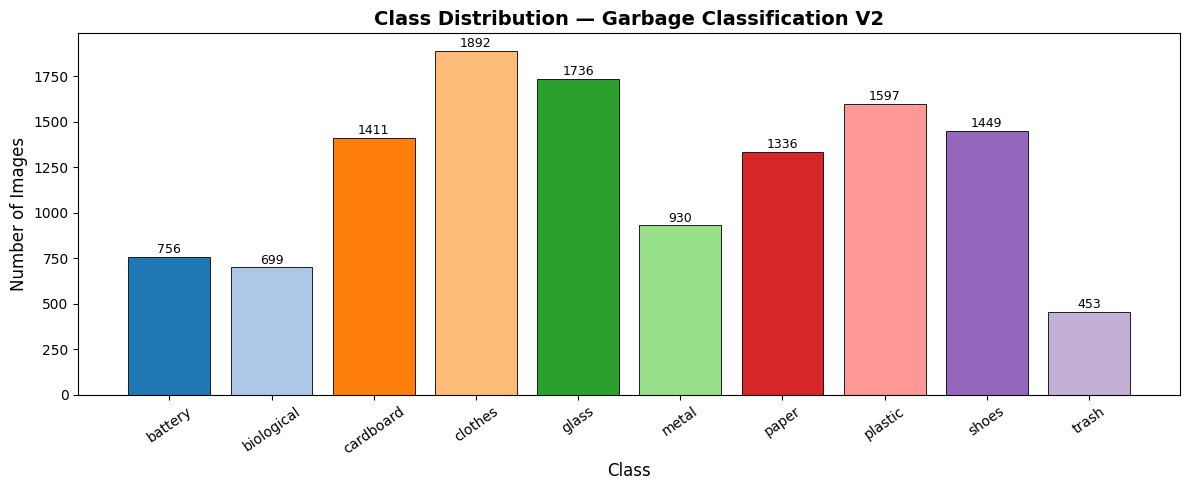

In [4]:
# 1.2 Bar chart of class distribution
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=plt.cm.tab20.colors[:len(class_counts)],
              edgecolor='black', linewidth=0.6)
ax.set_title("Class Distribution — Garbage Classification V2", fontsize=14, fontweight='bold')
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.tick_params(axis='x', rotation=35)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

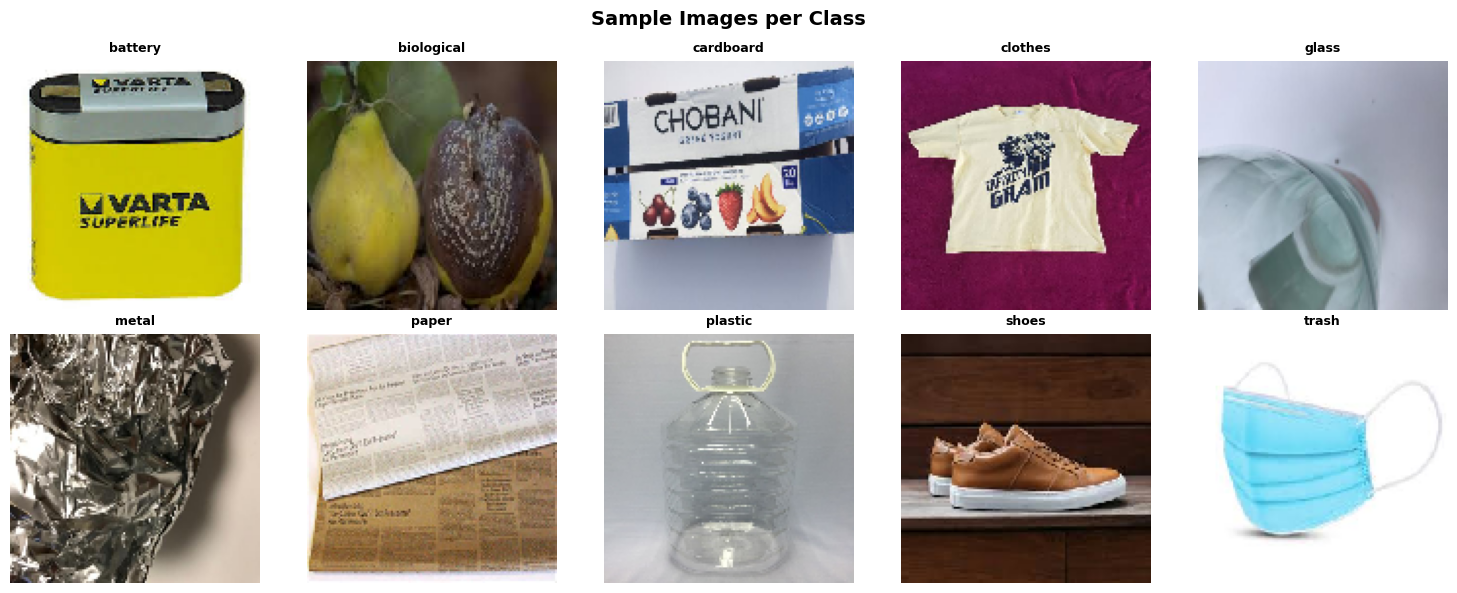

In [5]:
# 1.3 Sample images per class
n_cols = 5
n_rows = (len(class_names) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    cls_path = os.path.join(data_dir, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs:
        img = load_img(os.path.join(cls_path, imgs[0]), target_size=(128, 128))
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=9, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Sample Images per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 1.4 Global config & data generators
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
NUM_CLASSES = len(class_names)
SEED        = 42

train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    validation_split   = 0.20,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)
val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = 0.20
)

train_gen = train_datagen.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)

class_labels = list(train_gen.class_indices.keys())
print(f"Train samples : {train_gen.samples}")
print(f"Val   samples : {val_gen.samples}")
print(f"Classes       : {class_labels}")

Found 9811 images belonging to 10 classes.
Found 2448 images belonging to 10 classes.
Train samples : 9811
Val   samples : 2448
Classes       : ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


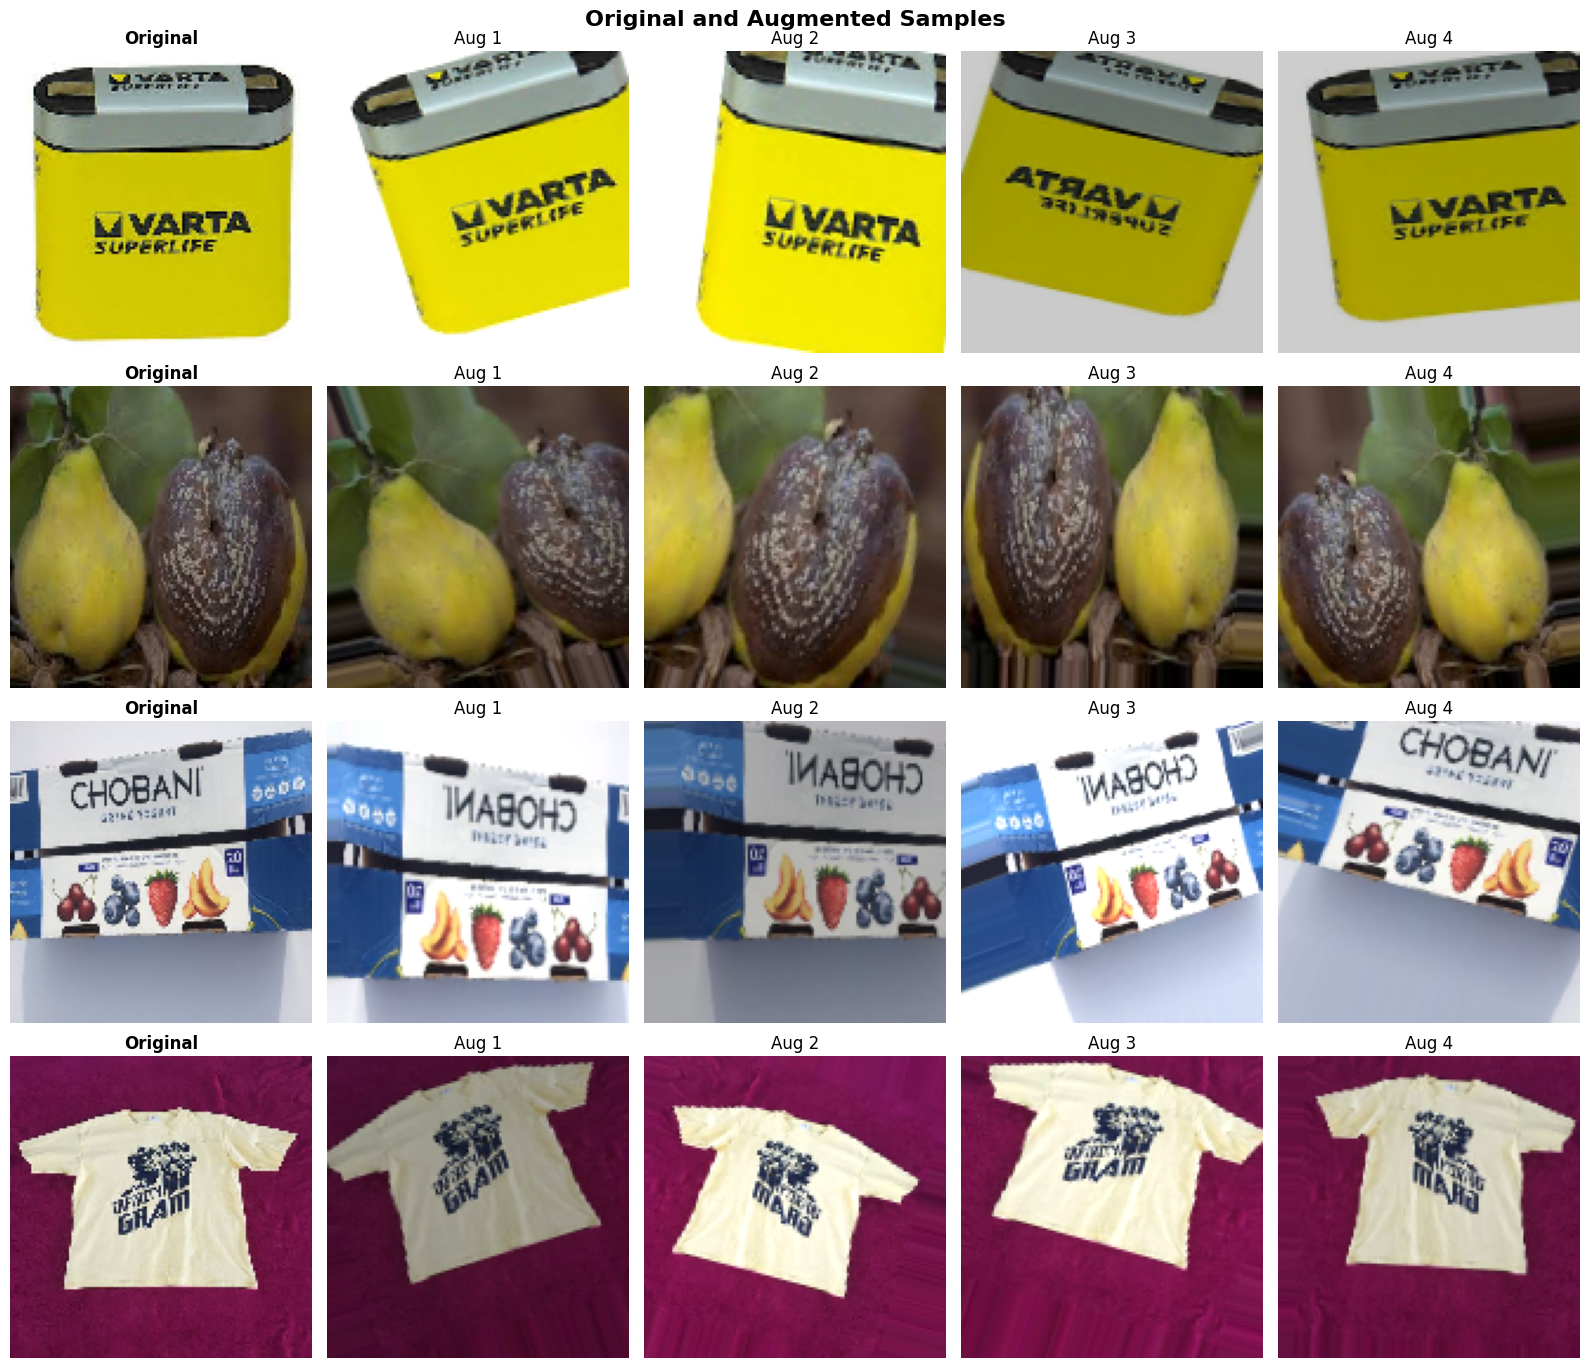

In [34]:
aug_gen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

# Collect 4 sample images
sample_images = []

for cls in class_names:
    cls_path = os.path.join(data_dir, cls)

    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(files) > 0:
        sample_images.append((cls, os.path.join(cls_path, files[0])))

    if len(sample_images) == 4:
        break

# Plot settings
fig, axes = plt.subplots(4, 5, figsize=(16, 14))

for row_idx, (cls_name, img_path) in enumerate(sample_images):

    # Load original image
    orig_img = load_img(img_path, target_size=IMG_SIZE)
    orig_arr = np.expand_dims(np.array(orig_img), axis=0)

    # Show original image
    axes[row_idx, 0].imshow(orig_img)
    axes[row_idx, 0].set_title("Original", fontweight='bold')
    axes[row_idx, 0].axis('off')

    # Generate augmented images
    aug_iter = aug_gen.flow(orig_arr, batch_size=1)

    for col_idx in range(1, 5):
        aug_img = next(aug_iter)[0].astype('uint8')

        axes[row_idx, col_idx].imshow(aug_img)
        axes[row_idx, col_idx].set_title(f"Aug {col_idx}")
        axes[row_idx, col_idx].axis('off')

    # Row label
    axes[row_idx, 0].set_ylabel(
        cls_name,
        fontsize=12,
        fontweight='bold'
    )

plt.suptitle(
    "Original and Augmented Samples",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig("augmented_samples_4_images.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Baseline CNN Model

In [8]:
# 2.1 Build Baseline CNN — 3 Conv blocks + 3 FC layers
def build_baseline_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    model = models.Sequential(name='Baseline_CNN')

    # Conv Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # Conv Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Conv Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # 3 Fully Connected layers
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64,  activation='relu'))

    # Output
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,914 (32.52 MB)

 Trainable params: 8,523,914 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 2.2 Train Baseline CNN
EPOCHS_BASELINE = 30

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_BASELINE,
    callbacks=callbacks_baseline,
    verbose=1
)
baseline_train_time = time.time() - t0
print(f"\nBaseline training time: {baseline_train_time:.1f}s  ({baseline_train_time/60:.1f} min)")

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 91s 265ms/step - accuracy: 0.2933 - loss: 1.9605 - val_accuracy: 0.4048 - val_loss: 1.7270 - learning_rate: 0.0010
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 77s 250ms/step - accuracy: 0.4340 - loss: 1.6280 - val_accuracy: 0.4690 - val_loss: 1.5224 - learning_rate: 0.0010
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 76s 247ms/step - accuracy: 0.4782 - loss: 1.5034 - val_accuracy: 0.5368 - val_loss: 1.3853 - learning_rate: 0.0010
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 75s 243ms/step - accuracy: 0.5242 - loss: 1.3862 - val_accuracy: 0.5359 - val_loss: 1.3846 - learning_rate: 0.0010
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 75s 246ms/step - accuracy: 0.5570 - loss: 1.3112 - val_accuracy: 0.5984 - val_loss: 1.1820 - learning_rate: 0.0010
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 74s 242ms/step - accuracy: 0.5786 - loss: 1.2420 - val_accuracy: 0.5662 - val_loss: 1.3217 - learning_rate: 0.0010
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 76s 247ms/step - accuracy: 0.5

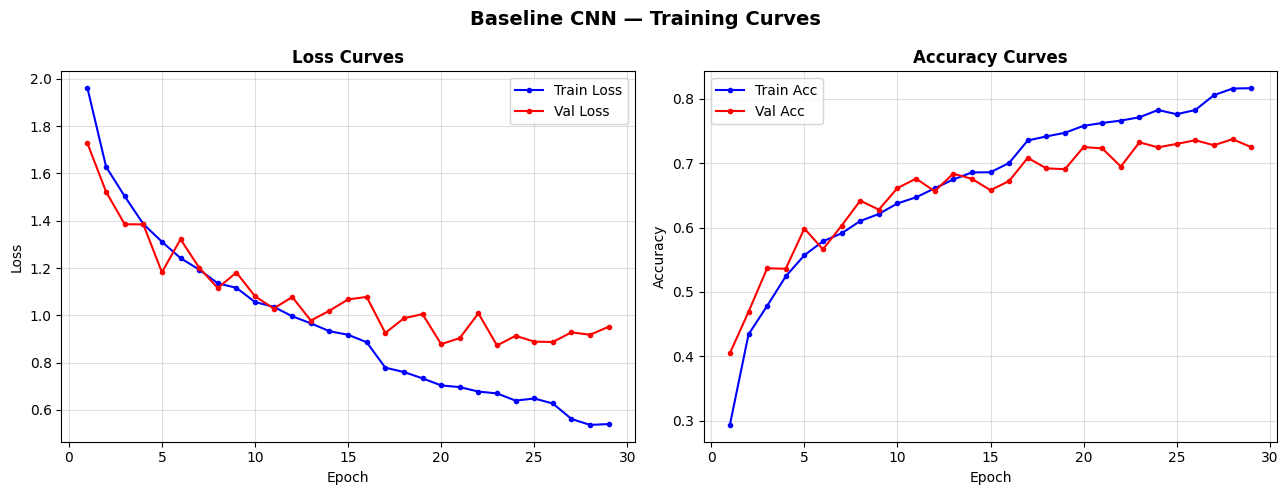

In [10]:
# 2.3 Plot training curves (reusable helper)
def plot_history(history, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    epochs = range(1, len(history.history['loss']) + 1)

    axes[0].plot(epochs, history.history['loss'],     'b-o', markersize=3, label='Train Loss')
    axes[0].plot(epochs, history.history['val_loss'], 'r-o', markersize=3, label='Val Loss')
    axes[0].set_title('Loss Curves', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.4)

    axes[1].plot(epochs, history.history['accuracy'],     'b-o', markersize=3, label='Train Acc')
    axes[1].plot(epochs, history.history['val_accuracy'], 'r-o', markersize=3, label='Val Acc')
    axes[1].set_title('Accuracy Curves', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.4)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, "Baseline CNN — Training Curves", "baseline_curves.png")

In [11]:
# 2.4 Evaluate Baseline CNN
val_gen.reset()
y_pred_baseline = np.argmax(baseline_model.predict(val_gen, verbose=0), axis=1)
y_true          = val_gen.classes

print("=" * 55)
print("BASELINE CNN — Classification Report")
print("=" * 55)
print(classification_report(y_true, y_pred_baseline, target_names=class_labels, digits=4))

baseline_val_acc = max(history_baseline.history['val_accuracy'])
print(f"Best Val Accuracy: {baseline_val_acc * 100:.2f}%")

BASELINE CNN — Classification Report
              precision    recall  f1-score   support

     battery     0.6944    0.8278    0.7553       151
  biological     0.8140    0.7554    0.7836       139
   cardboard     0.7386    0.8617    0.7954       282
     clothes     0.8553    0.8598    0.8575       378
       glass     0.6987    0.7550    0.7258       347
       metal     0.6118    0.5591    0.5843       186
       paper     0.6806    0.7341    0.7063       267
     plastic     0.7127    0.6144    0.6599       319
       shoes     0.8259    0.6401    0.7212       289
       trash     0.5306    0.5778    0.5532        90

    accuracy                         0.7324      2448
   macro avg     0.7162    0.7185    0.7143      2448
weighted avg     0.7358    0.7324    0.7309      2448

Best Val Accuracy: 73.73%


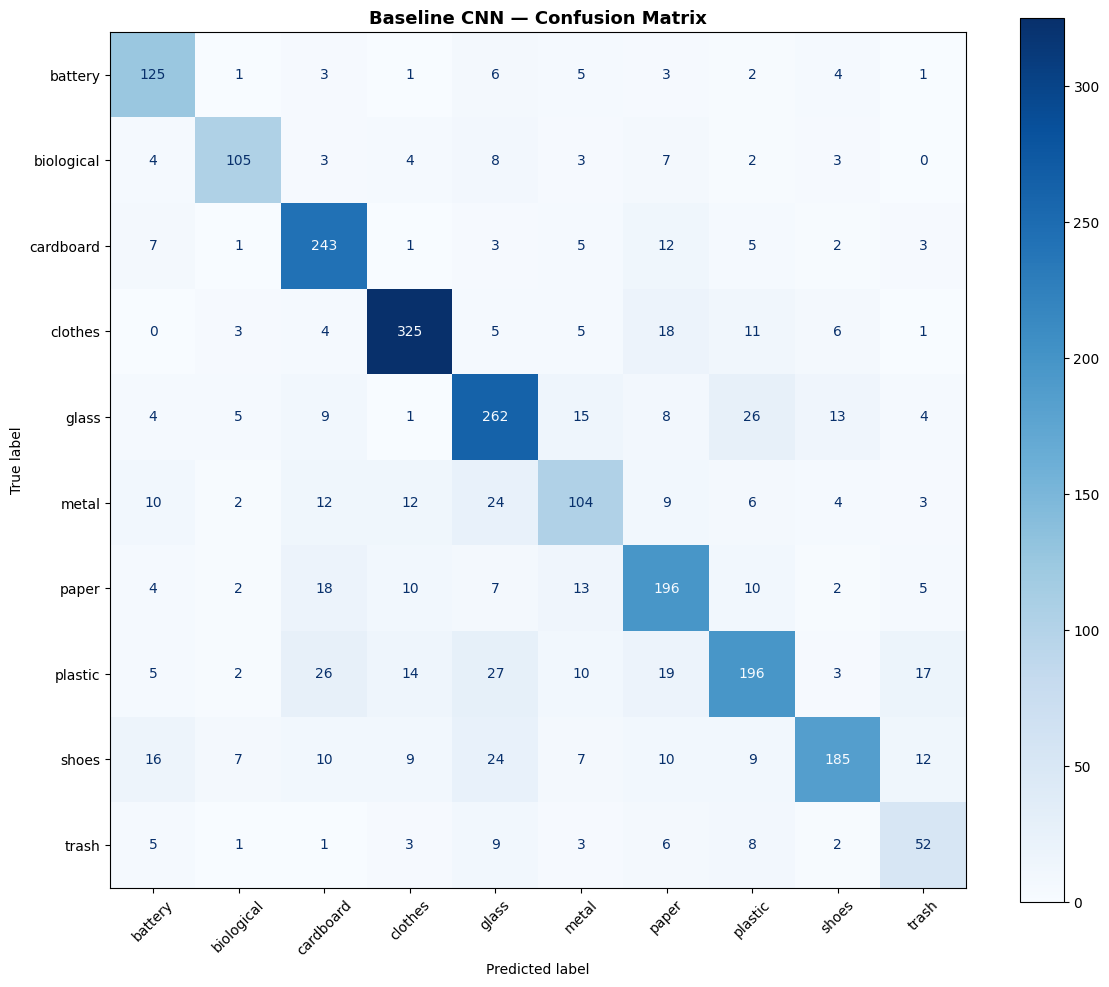

In [12]:
# 2.5 Confusion Matrix — Baseline
cm = confusion_matrix(y_true, y_pred_baseline)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
    ax=ax, xticks_rotation=45, cmap='Blues')
ax.set_title("Baseline CNN — Confusion Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

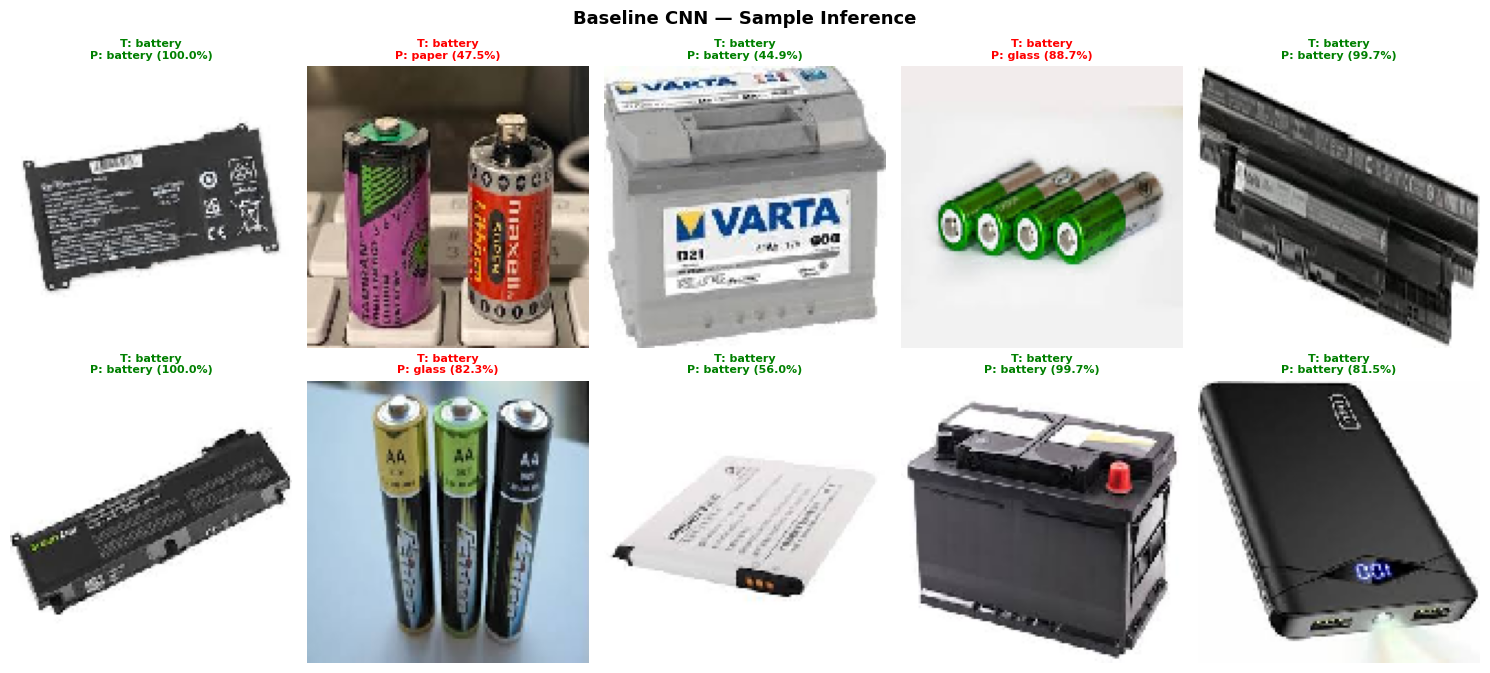

In [13]:
# 2.6 Inference on sample validation images (reusable helper)
def predict_and_plot(model, model_name, generator, labels, n=10):
    generator.reset()
    batch_imgs, batch_lbls = next(generator)
    preds = model.predict(batch_imgs, verbose=0)
    n = min(n, len(batch_imgs))
    cols = 5
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    axes = axes.flatten()
    for i in range(n):
        axes[i].imshow(batch_imgs[i])
        true_lbl  = labels[np.argmax(batch_lbls[i])]
        pred_lbl  = labels[np.argmax(preds[i])]
        conf      = np.max(preds[i]) * 100
        color     = 'green' if true_lbl == pred_lbl else 'red'
        axes[i].set_title(f"T: {true_lbl}\nP: {pred_lbl} ({conf:.1f}%)",
                          fontsize=8, color=color, fontweight='bold')
        axes[i].axis('off')
    for j in range(n, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"{model_name} — Sample Inference", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{model_name.replace(' ','_')}_inference.png", dpi=150, bbox_inches='tight')
    plt.show()

predict_and_plot(baseline_model, "Baseline CNN", val_gen, class_labels)

---
## 3. Deeper CNN with Regularization

In [14]:
# 3.1 Build Deeper CNN — 4 double-conv blocks + BatchNorm + Dropout + L2
def build_deeper_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    model = models.Sequential(name='Deeper_CNN')

    for filters, drop_rate in [(32, 0.25), (64, 0.25), (128, 0.25), (256, 0.30)]:
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu',
                                input_shape=input_shape if filters == 32 else None))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2,2)))
        model.add(layers.Dropout(drop_rate))
        input_shape = None  # only used for first layer

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.40))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

deeper_model = build_deeper_cnn()
deeper_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,702,186 (37.01 MB)

 Trainable params: 9,698,730 (37.00 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [15]:
# 3.2 Train Deeper CNN
EPOCHS_DEEPER = 40

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_deeper_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

t0 = time.time()
history_deeper = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_DEEPER,
    callbacks=callbacks_deeper,
    verbose=1
)
deeper_train_time = time.time() - t0
print(f"\nDeeper CNN training time: {deeper_train_time:.1f}s  ({deeper_train_time/60:.1f} min)")

Epoch 1/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 124s 328ms/step - accuracy: 0.2627 - loss: 2.5660 - val_accuracy: 0.2149 - val_loss: 2.6971 - learning_rate: 0.0010
Epoch 2/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 82s 267ms/step - accuracy: 0.3833 - loss: 2.0580 - val_accuracy: 0.4926 - val_loss: 1.6981 - learning_rate: 0.0010
Epoch 3/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 81s 263ms/step - accuracy: 0.4455 - loss: 1.8532 - val_accuracy: 0.3117 - val_loss: 2.4582 - learning_rate: 0.0010
Epoch 4/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 85s 278ms/step - accuracy: 0.4833 - loss: 1.7362 - val_accuracy: 0.4922 - val_loss: 1.7510 - learning_rate: 0.0010
Epoch 5/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 261ms/step - accuracy: 0.5144 - loss: 1.6699 - val_accuracy: 0.3623 - val_loss: 2.2914 - learning_rate: 0.0010
Epoch 6/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5317 - loss: 1.6098
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
307/307 ━━━━━━━━━━━━━━━━━━━━ 88s 286ms/step - accuracy: 0.53

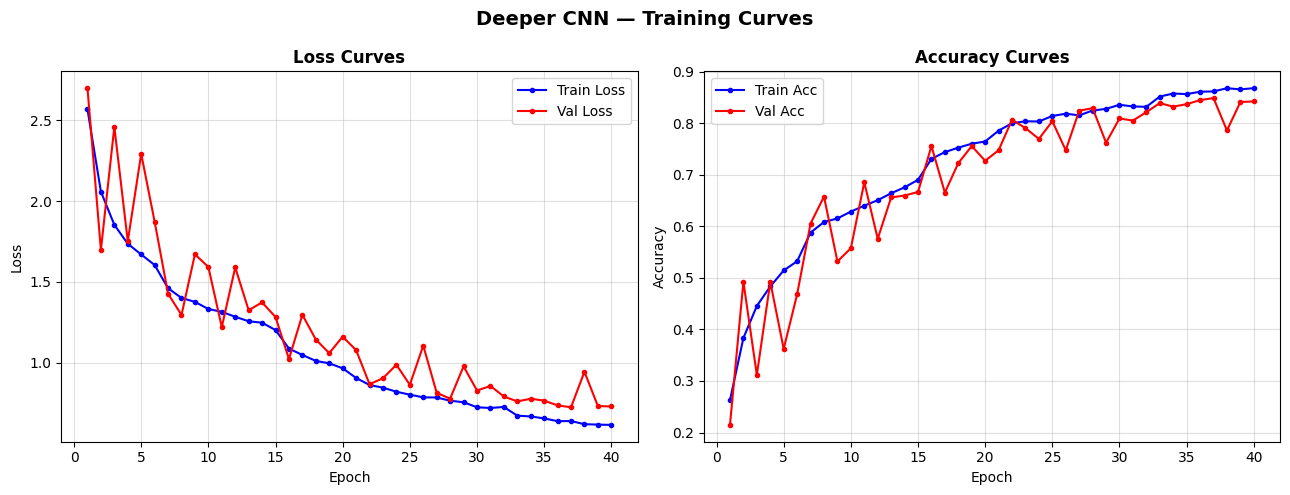

In [16]:
# 3.3 Training curves
plot_history(history_deeper, "Deeper CNN — Training Curves", "deeper_curves.png")

In [17]:
# 3.4 Evaluate Deeper CNN
val_gen.reset()
y_pred_deeper = np.argmax(deeper_model.predict(val_gen, verbose=0), axis=1)
y_true        = val_gen.classes

print("=" * 55)
print("DEEPER CNN — Classification Report")
print("=" * 55)
print(classification_report(y_true, y_pred_deeper, target_names=class_labels, digits=4))

deeper_val_acc = max(history_deeper.history['val_accuracy'])
print(f"Best Val Accuracy: {deeper_val_acc * 100:.2f}%")

DEEPER CNN — Classification Report
              precision    recall  f1-score   support

     battery     0.9048    0.8808    0.8926       151
  biological     0.9037    0.8777    0.8905       139
   cardboard     0.8759    0.8759    0.8759       282
     clothes     0.9066    0.9497    0.9276       378
       glass     0.8550    0.8156    0.8348       347
       metal     0.7333    0.8280    0.7778       186
       paper     0.7986    0.8764    0.8357       267
     plastic     0.8333    0.7367    0.7820       319
       shoes     0.8724    0.8754    0.8739       289
       trash     0.7073    0.6444    0.6744        90

    accuracy                         0.8489      2448
   macro avg     0.8391    0.8361    0.8365      2448
weighted avg     0.8496    0.8489    0.8482      2448

Best Val Accuracy: 84.89%


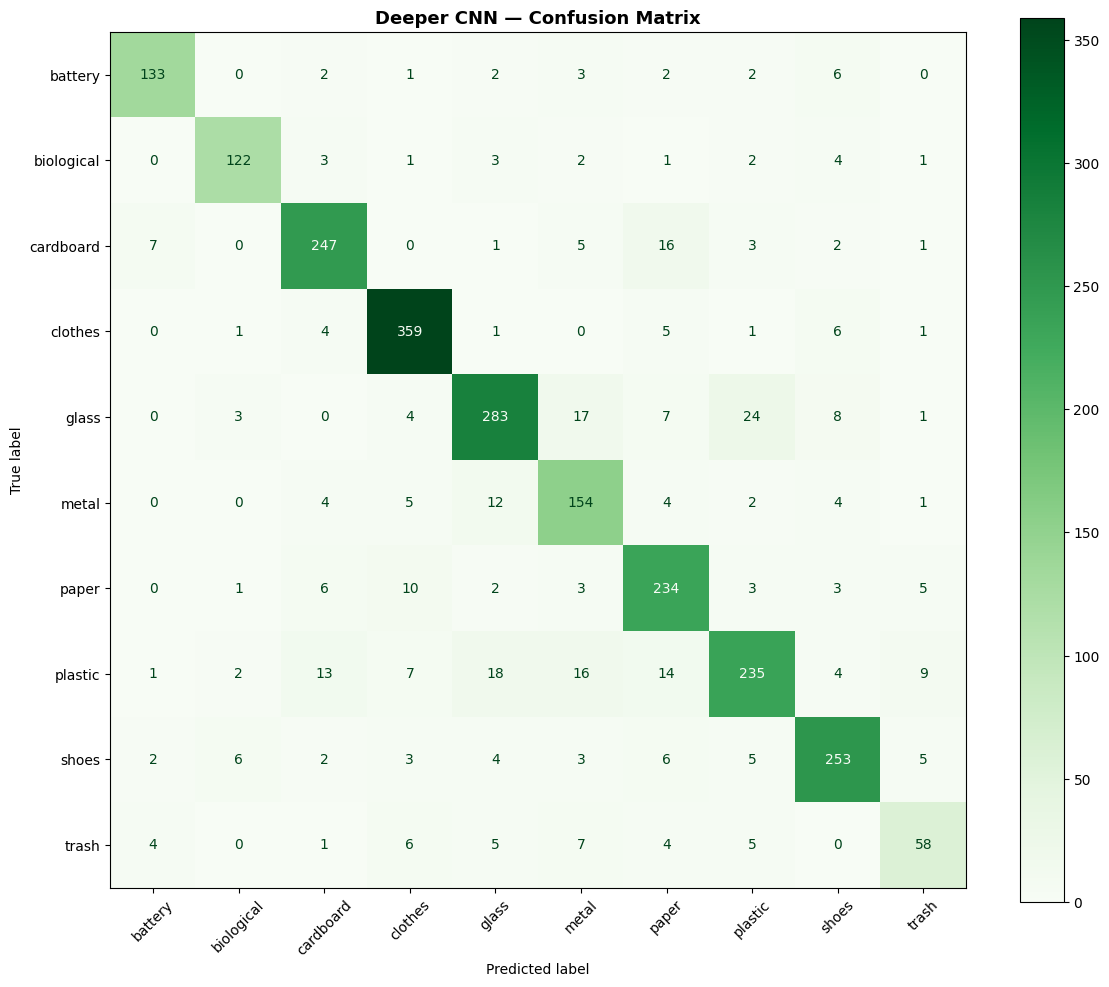

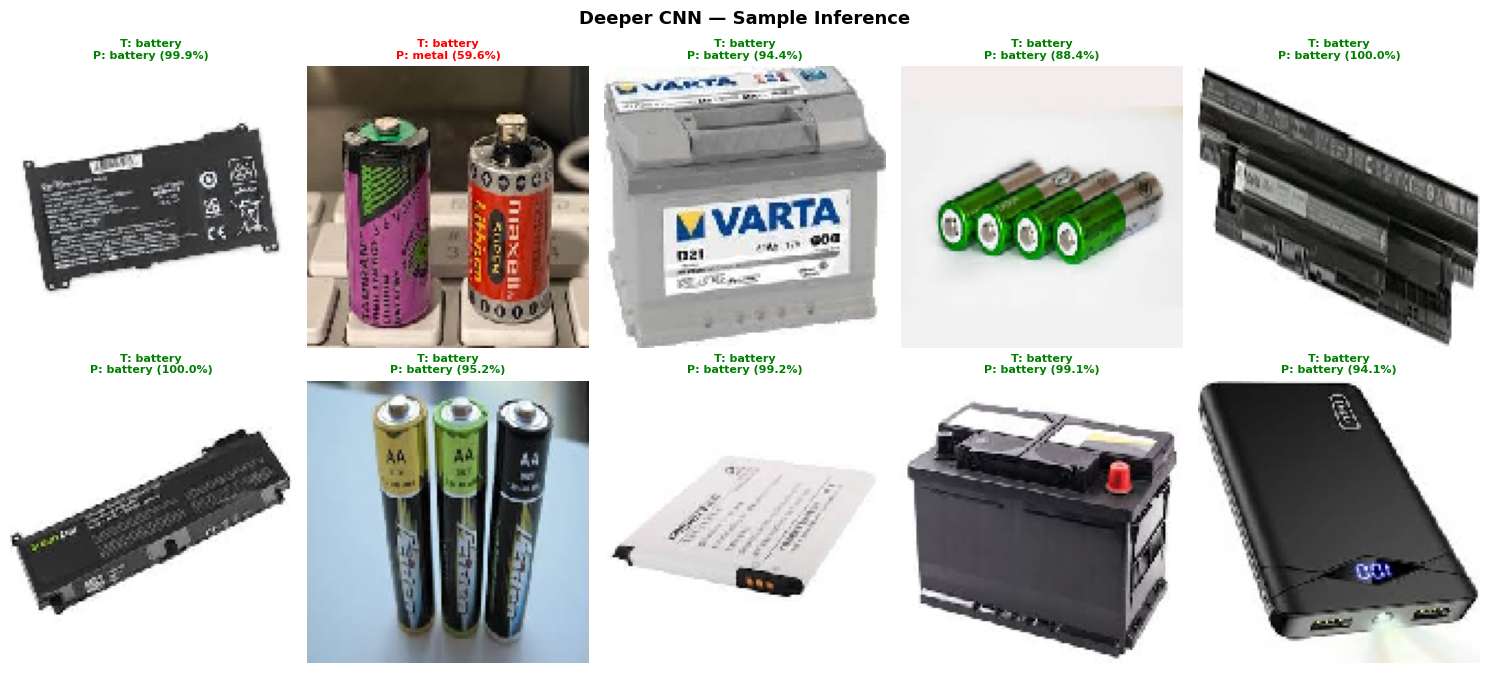

In [18]:
# 3.5 Confusion Matrix + inference
cm_deeper = confusion_matrix(y_true, y_pred_deeper)
fig, ax   = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_deeper, display_labels=class_labels).plot(
    ax=ax, xticks_rotation=45, cmap='Greens')
ax.set_title("Deeper CNN — Confusion Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("deeper_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

predict_and_plot(deeper_model, "Deeper CNN", val_gen, class_labels)

---
## 4. Experimentation & Comparative Analysis

In [19]:
# 4.1 SGD vs Adam — train deeper model with SGD+Momentum
model_sgd = build_deeper_cnn()
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_sgd = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_sgd = model_sgd.fit(
    train_gen, validation_data=val_gen,
    epochs=40, callbacks=cb_sgd, verbose=1
)
sgd_time    = time.time() - t0
sgd_val_acc = max(history_sgd.history['val_accuracy'])
print(f"SGD Training Time: {sgd_time/60:.1f} min  |  Best Val Acc: {sgd_val_acc*100:.2f}%")

Epoch 1/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 294ms/step - accuracy: 0.2624 - loss: 2.4458 - val_accuracy: 0.3207 - val_loss: 2.1594 - learning_rate: 0.0100
Epoch 2/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 260ms/step - accuracy: 0.3156 - loss: 2.1510 - val_accuracy: 0.4003 - val_loss: 1.8942 - learning_rate: 0.0100
Epoch 3/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 84s 272ms/step - accuracy: 0.3494 - loss: 2.0508 - val_accuracy: 0.4408 - val_loss: 1.7211 - learning_rate: 0.0100
Epoch 4/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 261ms/step - accuracy: 0.3747 - loss: 1.9600 - val_accuracy: 0.3150 - val_loss: 2.4126 - learning_rate: 0.0100
Epoch 5/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 81s 263ms/step - accuracy: 0.4090 - loss: 1.8748 - val_accuracy: 0.2855 - val_loss: 2.4056 - learning_rate: 0.0100
Epoch 6/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 81s 265ms/step - accuracy: 0.4254 - loss: 1.8453 - val_accuracy: 0.4011 - val_loss: 1.8798 - learning_rate: 0.0100
Epoch 7/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.4

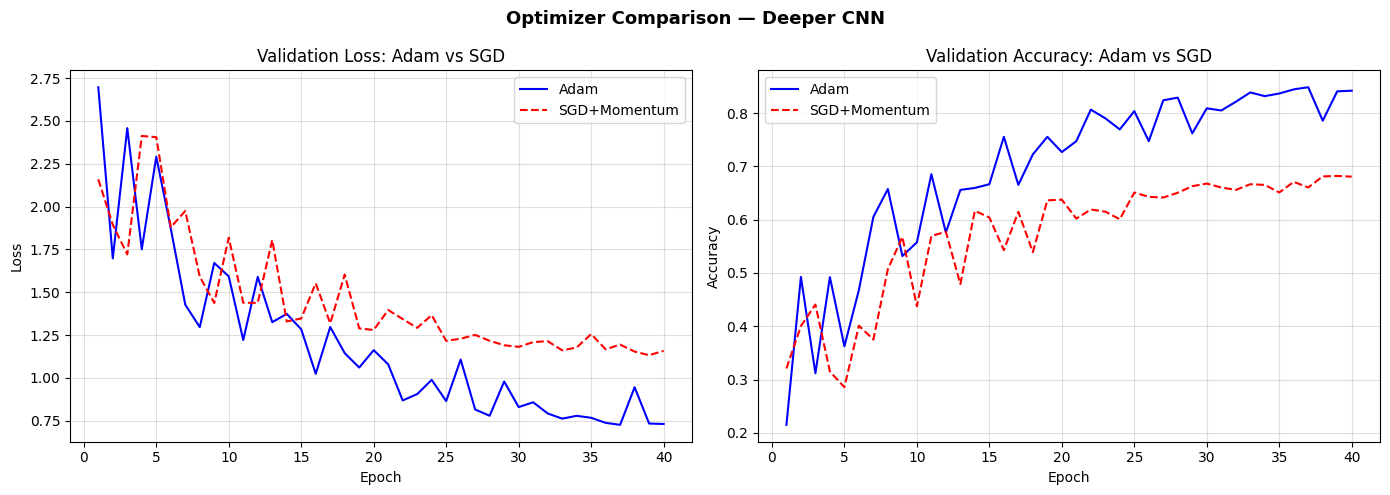

In [20]:
# 4.2 SGD vs Adam comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

e_adam = range(1, len(history_deeper.history['val_accuracy']) + 1)
e_sgd  = range(1, len(history_sgd.history['val_accuracy'])   + 1)

axes[0].plot(e_adam, history_deeper.history['val_loss'],     'b-',  label='Adam')
axes[0].plot(e_sgd,  history_sgd.history['val_loss'],        'r--', label='SGD+Momentum')
axes[0].set_title('Validation Loss: Adam vs SGD')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(e_adam, history_deeper.history['val_accuracy'], 'b-',  label='Adam')
axes[1].plot(e_sgd,  history_sgd.history['val_accuracy'],    'r--', label='SGD+Momentum')
axes[1].set_title('Validation Accuracy: Adam vs SGD')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle('Optimizer Comparison — Deeper CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("optimizer_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# 4.3 Ablation Study — Deeper CNN WITHOUT Dropout
def build_no_dropout_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):
    model = models.Sequential(name='No_Dropout_CNN')
    for filters in [32, 64, 128, 256]:
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu',
                                input_shape=input_shape if filters == 32 else None))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2,2)))
        # NO DROPOUT — ablation
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

model_nodrop = build_no_dropout_cnn()
model_nodrop.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cb_nd = [EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)]

t0 = time.time()
history_nodrop = model_nodrop.fit(
    train_gen, validation_data=val_gen,
    epochs=40, callbacks=cb_nd, verbose=1
)
nodrop_time    = time.time() - t0
nodrop_val_acc = max(history_nodrop.history['val_accuracy'])
print(f"No-Dropout Val Acc: {nodrop_val_acc*100:.2f}%")

Epoch 1/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 98s 281ms/step - accuracy: 0.3894 - loss: 1.9791 - val_accuracy: 0.1895 - val_loss: 2.6555
Epoch 2/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 262ms/step - accuracy: 0.4753 - loss: 1.6975 - val_accuracy: 0.5266 - val_loss: 1.6554
Epoch 3/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 81s 263ms/step - accuracy: 0.5343 - loss: 1.5465 - val_accuracy: 0.3803 - val_loss: 2.1318
Epoch 4/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 260ms/step - accuracy: 0.5547 - loss: 1.4928 - val_accuracy: 0.4244 - val_loss: 2.0579
Epoch 5/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 259ms/step - accuracy: 0.5934 - loss: 1.4005 - val_accuracy: 0.5919 - val_loss: 1.4691
Epoch 6/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 261ms/step - accuracy: 0.6146 - loss: 1.3337 - val_accuracy: 0.4959 - val_loss: 1.8595
Epoch 7/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 79s 259ms/step - accuracy: 0.6402 - loss: 1.2749 - val_accuracy: 0.5752 - val_loss: 1.5873
Epoch 8/40
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 259ms/step - accuracy: 0.6574 - loss: 1

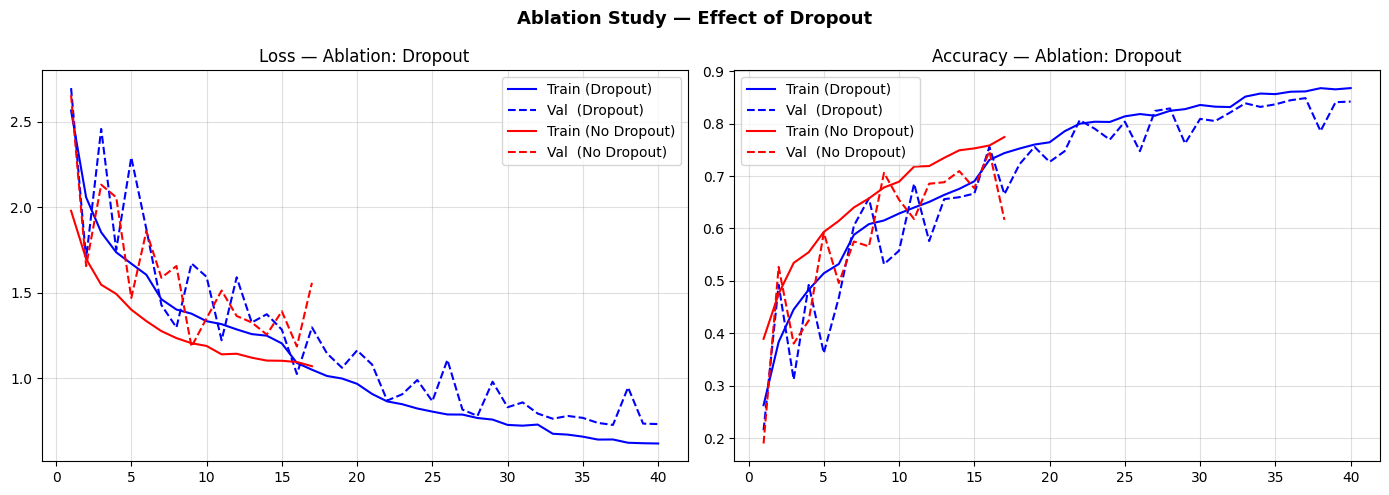

With Dropout    — Val Acc: 84.89%
Without Dropout — Val Acc: 74.75%


In [22]:
# 4.4 Ablation plot — Dropout vs No-Dropout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

e_d  = range(1, len(history_deeper.history['loss'])   + 1)
e_nd = range(1, len(history_nodrop.history['loss'])   + 1)

axes[0].plot(e_d,  history_deeper.history['loss'],       'b-',  label='Train (Dropout)')
axes[0].plot(e_d,  history_deeper.history['val_loss'],   'b--', label='Val  (Dropout)')
axes[0].plot(e_nd, history_nodrop.history['loss'],       'r-',  label='Train (No Dropout)')
axes[0].plot(e_nd, history_nodrop.history['val_loss'],   'r--', label='Val  (No Dropout)')
axes[0].set_title('Loss — Ablation: Dropout'); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(e_d,  history_deeper.history['accuracy'],     'b-',  label='Train (Dropout)')
axes[1].plot(e_d,  history_deeper.history['val_accuracy'], 'b--', label='Val  (Dropout)')
axes[1].plot(e_nd, history_nodrop.history['accuracy'],     'r-',  label='Train (No Dropout)')
axes[1].plot(e_nd, history_nodrop.history['val_accuracy'], 'r--', label='Val  (No Dropout)')
axes[1].set_title('Accuracy — Ablation: Dropout'); axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle('Ablation Study — Effect of Dropout', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("ablation_dropout.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"With Dropout    — Val Acc: {deeper_val_acc*100:.2f}%")
print(f"Without Dropout — Val Acc: {nodrop_val_acc*100:.2f}%")

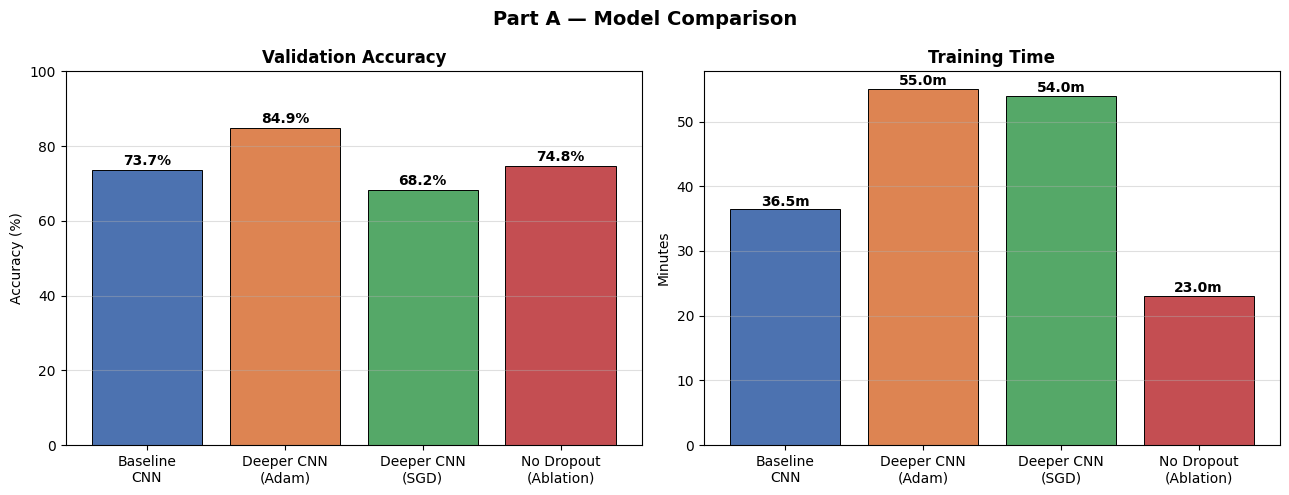

In [23]:
# 4.5 Part A summary bar chart
model_names = ['Baseline\nCNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)', 'No Dropout\n(Ablation)']
val_accs    = [baseline_val_acc, deeper_val_acc, sgd_val_acc, nodrop_val_acc]
train_times = [baseline_train_time, deeper_train_time, sgd_time, nodrop_time]
colors      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(model_names, [a*100 for a in val_accs],
                    color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Validation Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars1, val_accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val*100:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(model_names, [t/60 for t in train_times],
                    color=colors, edgecolor='black', linewidth=0.7)
axes[1].set_title('Training Time', fontweight='bold')
axes[1].set_ylabel('Minutes'); axes[1].grid(axis='y', alpha=0.4)
for bar, t in zip(bars2, train_times):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{t/60:.1f}m", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Part A — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("partA_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Part B — VGG16 Transfer Learning
---

In [24]:
# B.1 Data generators for VGG16 (224x224 + VGG preprocessing)
IMG_SIZE_VGG = (224, 224)

train_datagen_vgg = ImageDataGenerator(
    preprocessing_function = vgg_preprocess,
    validation_split       = 0.20,
    rotation_range         = 20,
    width_shift_range      = 0.15,
    height_shift_range     = 0.15,
    zoom_range             = 0.15,
    horizontal_flip        = True,
    fill_mode              = 'nearest'
)
val_datagen_vgg = ImageDataGenerator(
    preprocessing_function = vgg_preprocess,
    validation_split       = 0.20
)

train_gen_vgg = train_datagen_vgg.flow_from_directory(
    data_dir, target_size=IMG_SIZE_VGG, batch_size=32,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True
)
val_gen_vgg = val_datagen_vgg.flow_from_directory(
    data_dir, target_size=IMG_SIZE_VGG, batch_size=32,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False
)

class_labels_vgg = list(train_gen_vgg.class_indices.keys())
print(f"VGG Train: {train_gen_vgg.samples}  |  Val: {val_gen_vgg.samples}")

Found 9811 images belonging to 10 classes.
Found 2448 images belonging to 10 classes.
VGG Train: 9811  |  Val: 2448


In [25]:
# B.2 Load VGG16 + custom classification head
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Phase 1: freeze convolutional base

inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.50)(x)
x       = layers.Dense(256, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

vgg_model = keras.Model(inputs, outputs, name='VGG16_Transfer')
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,290 (57.65 MB)

 Trainable params: 397,578 (1.52 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [26]:
# B.3 Phase 1 — Feature Extraction (frozen VGG16 base)
print("PHASE 1: Feature Extraction")

cb_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

t0 = time.time()
history_vgg_p1 = vgg_model.fit(
    train_gen_vgg, validation_data=val_gen_vgg,
    epochs=15, callbacks=cb_p1, verbose=1
)
phase1_time = time.time() - t0
print(f"Phase 1 time: {phase1_time/60:.1f} min")

PHASE 1: Feature Extraction
Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 211s 621ms/step - accuracy: 0.7477 - loss: 0.8924 - val_accuracy: 0.8864 - val_loss: 0.4650 - learning_rate: 0.0010
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 168s 548ms/step - accuracy: 0.8331 - loss: 0.6086 - val_accuracy: 0.8975 - val_loss: 0.4251 - learning_rate: 0.0010
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 169s 549ms/step - accuracy: 0.8553 - loss: 0.5267 - val_accuracy: 0.9007 - val_loss: 0.3999 - learning_rate: 0.0010
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 166s 540ms/step - accuracy: 0.8772 - loss: 0.4754 - val_accuracy: 0.9109 - val_loss: 0.3842 - learning_rate: 0.0010
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 166s 540ms/step - accuracy: 0.8785 - loss: 0.4630 - val_accuracy: 0.9183 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 166s 542ms/step - accuracy: 0.8843 - loss: 0.4484 - val_accuracy: 0.9060 - val_loss: 0.4028 - learning_rate: 0.0010
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━

In [27]:
# B.4 Phase 2 — Fine-Tuning (unfreeze VGG16 block5)
print("PHASE 2: Fine-Tuning block5")

base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = layer.name.startswith('block5')

# Lower LR to avoid catastrophic forgetting
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_p2 = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_vgg16_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

t0 = time.time()
history_vgg_p2 = vgg_model.fit(
    train_gen_vgg, validation_data=val_gen_vgg,
    epochs=25, callbacks=cb_p2, verbose=1
)
phase2_time     = time.time() - t0
vgg_total_time  = phase1_time + phase2_time
print(f"Phase 2: {phase2_time/60:.1f} min  |  Total: {vgg_total_time/60:.1f} min")

PHASE 2: Fine-Tuning block5
Epoch 1/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 188s 584ms/step - accuracy: 0.9290 - loss: 0.3300 - val_accuracy: 0.9326 - val_loss: 0.3416 - learning_rate: 1.0000e-05
Epoch 2/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 173s 561ms/step - accuracy: 0.9399 - loss: 0.3034 - val_accuracy: 0.9359 - val_loss: 0.3400 - learning_rate: 1.0000e-05
Epoch 3/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 171s 556ms/step - accuracy: 0.9462 - loss: 0.2821 - val_accuracy: 0.9395 - val_loss: 0.3275 - learning_rate: 1.0000e-05
Epoch 4/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 170s 552ms/step - accuracy: 0.9493 - loss: 0.2720 - val_accuracy: 0.9391 - val_loss: 0.3328 - learning_rate: 1.0000e-05
Epoch 5/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 172s 561ms/step - accuracy: 0.9523 - loss: 0.2630 - val_accuracy: 0.9424 - val_loss: 0.3143 - learning_rate: 1.0000e-05
Epoch 6/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 172s 560ms/step - accuracy: 0.9593 - loss: 0.2414 - val_accuracy: 0.9436 - val_loss: 0.3149 - learning_rate: 1.0000e-05
Epoch 7/25
3

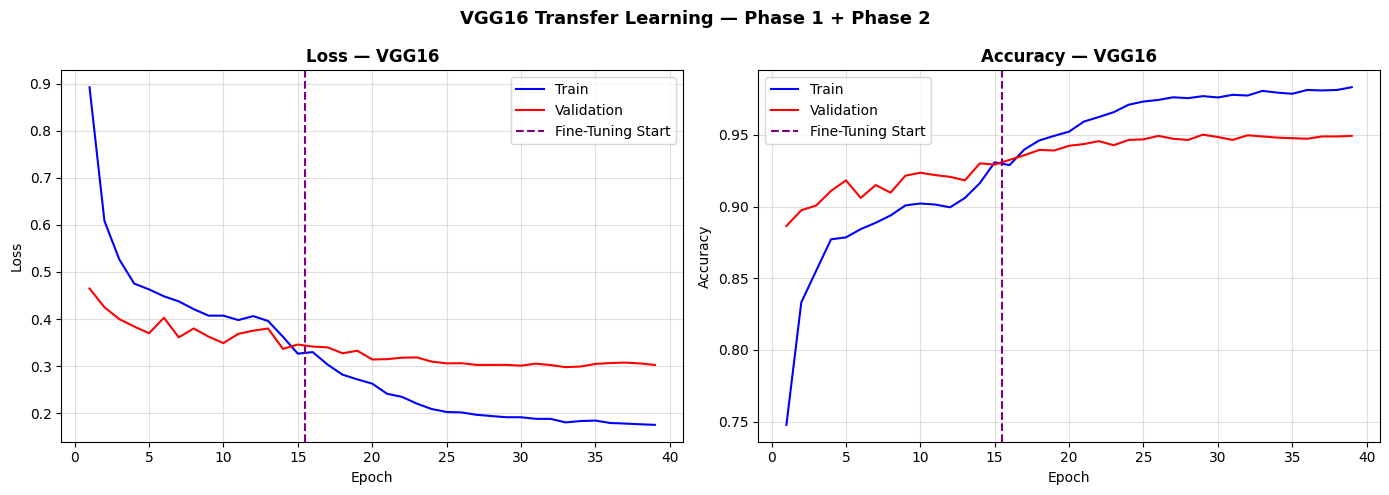

In [28]:
# B.5 VGG16 training curves (Phase 1 + 2 combined)
train_loss = history_vgg_p1.history['loss']         + history_vgg_p2.history['loss']
val_loss   = history_vgg_p1.history['val_loss']     + history_vgg_p2.history['val_loss']
train_acc  = history_vgg_p1.history['accuracy']     + history_vgg_p2.history['accuracy']
val_acc    = history_vgg_p1.history['val_accuracy'] + history_vgg_p2.history['val_accuracy']
epochs_all = range(1, len(train_loss) + 1)
p1_end     = len(history_vgg_p1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (tr, vl, ylab) in zip(axes,
        [(train_loss, val_loss, 'Loss'), (train_acc, val_acc, 'Accuracy')]):
    ax.plot(epochs_all, tr, 'b-', label='Train')
    ax.plot(epochs_all, vl, 'r-', label='Validation')
    ax.axvline(p1_end + 0.5, color='purple', linestyle='--',
               linewidth=1.5, label='Fine-Tuning Start')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylab)
    ax.set_title(f'{ylab} — VGG16', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.4)

plt.suptitle('VGG16 Transfer Learning — Phase 1 + Phase 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("vgg16_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# B.6 Evaluate VGG16
val_gen_vgg.reset()
y_pred_vgg = np.argmax(vgg_model.predict(val_gen_vgg, verbose=0), axis=1)
y_true_vgg = val_gen_vgg.classes

print("=" * 57)
print("VGG16 TRANSFER LEARNING — Classification Report")
print("=" * 57)
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_labels_vgg, digits=4))

vgg_val_acc = max(history_vgg_p1.history['val_accuracy'] + history_vgg_p2.history['val_accuracy'])
print(f"Best VGG16 Val Accuracy: {vgg_val_acc * 100:.2f}%")

VGG16 TRANSFER LEARNING — Classification Report
              precision    recall  f1-score   support

     battery     0.9610    0.9801    0.9705       151
  biological     0.9784    0.9784    0.9784       139
   cardboard     0.9774    0.9184    0.9470       282
     clothes     0.9947    0.9894    0.9920       378
       glass     0.9525    0.9251    0.9386       347
       metal     0.9171    0.9516    0.9340       186
       paper     0.8881    0.9513    0.9186       267
     plastic     0.9331    0.9185    0.9258       319
       shoes     0.9795    0.9896    0.9845       289
       trash     0.8152    0.8333    0.8242        90

    accuracy                         0.9489      2448
   macro avg     0.9397    0.9436    0.9414      2448
weighted avg     0.9498    0.9489    0.9491      2448

Best VGG16 Val Accuracy: 95.02%


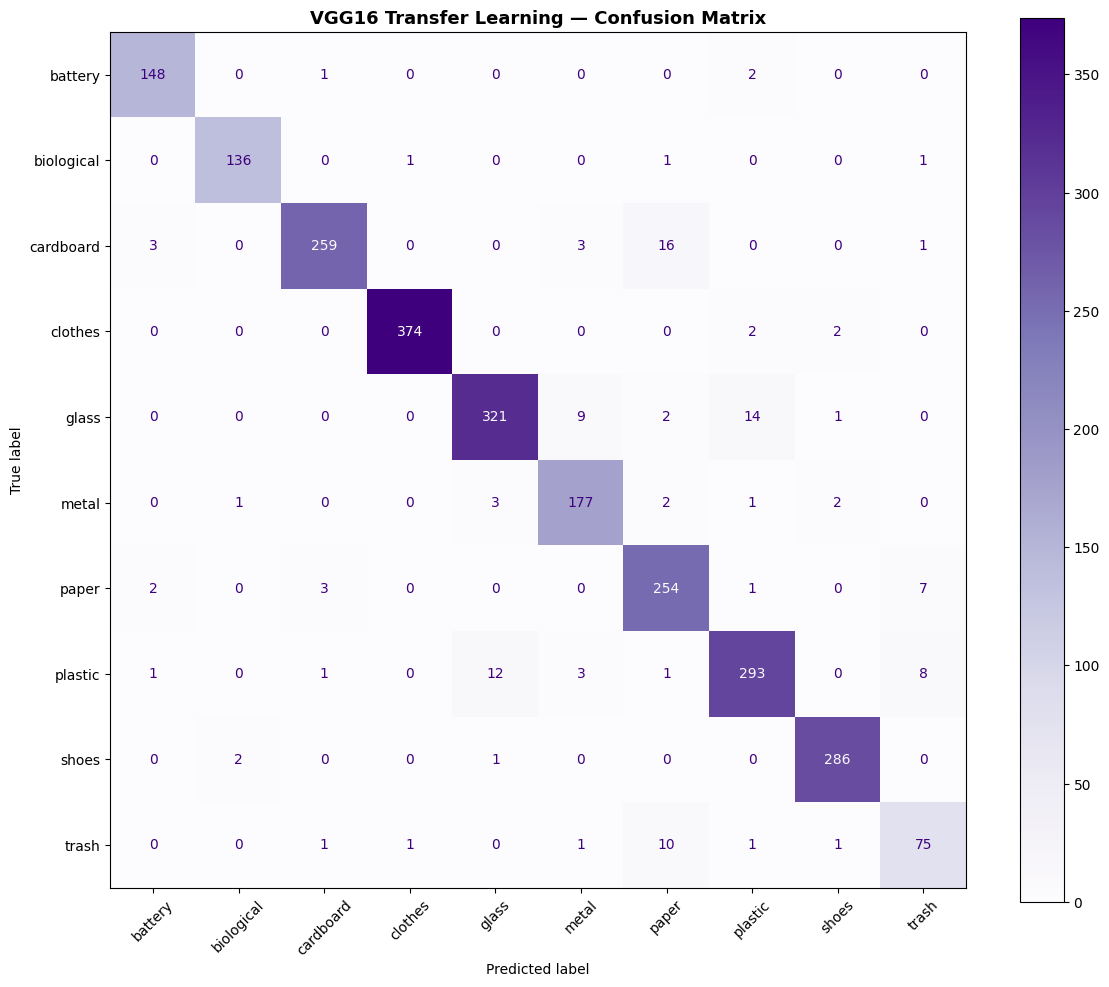

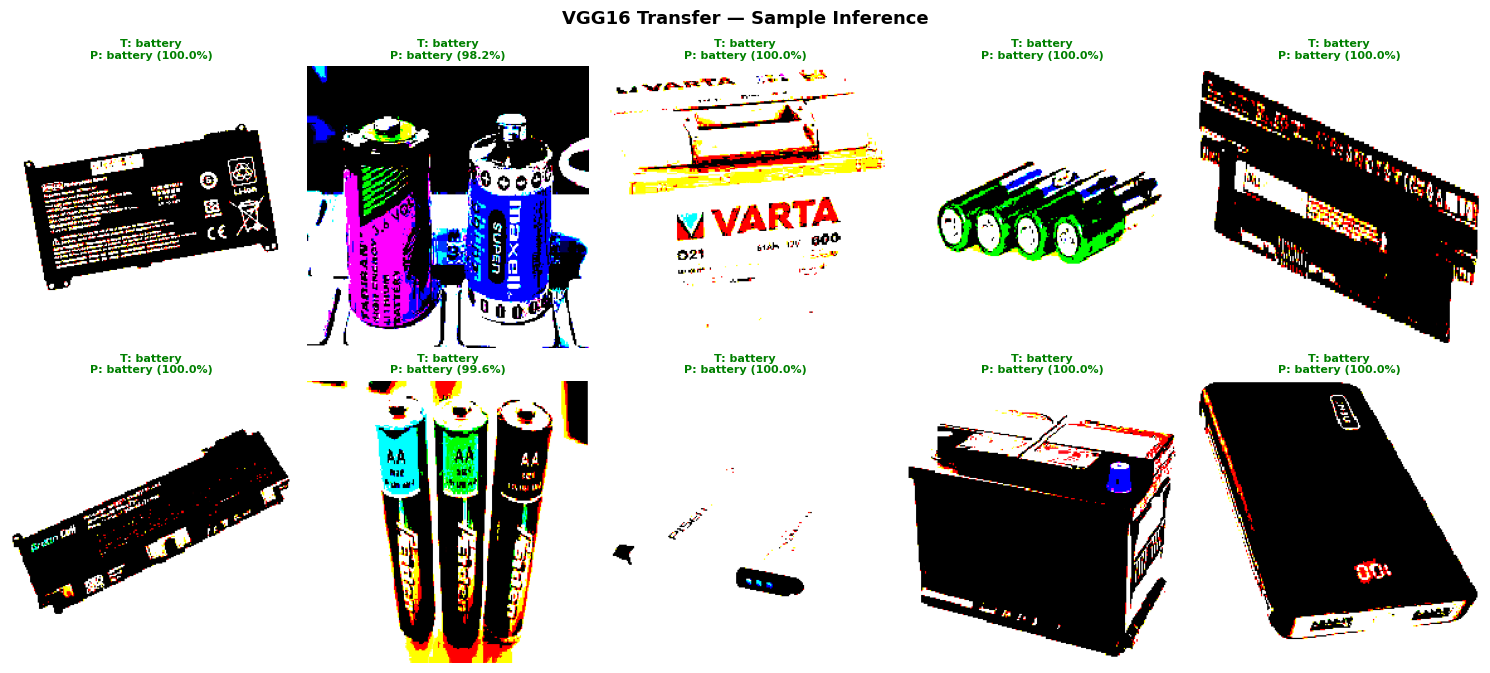

In [30]:
# B.7 Confusion Matrix + inference
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm_vgg, display_labels=class_labels_vgg).plot(
    ax=ax, xticks_rotation=45, cmap='Purples')
ax.set_title("VGG16 Transfer Learning — Confusion Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("vgg16_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

predict_and_plot(vgg_model, "VGG16 Transfer", val_gen_vgg, class_labels_vgg)

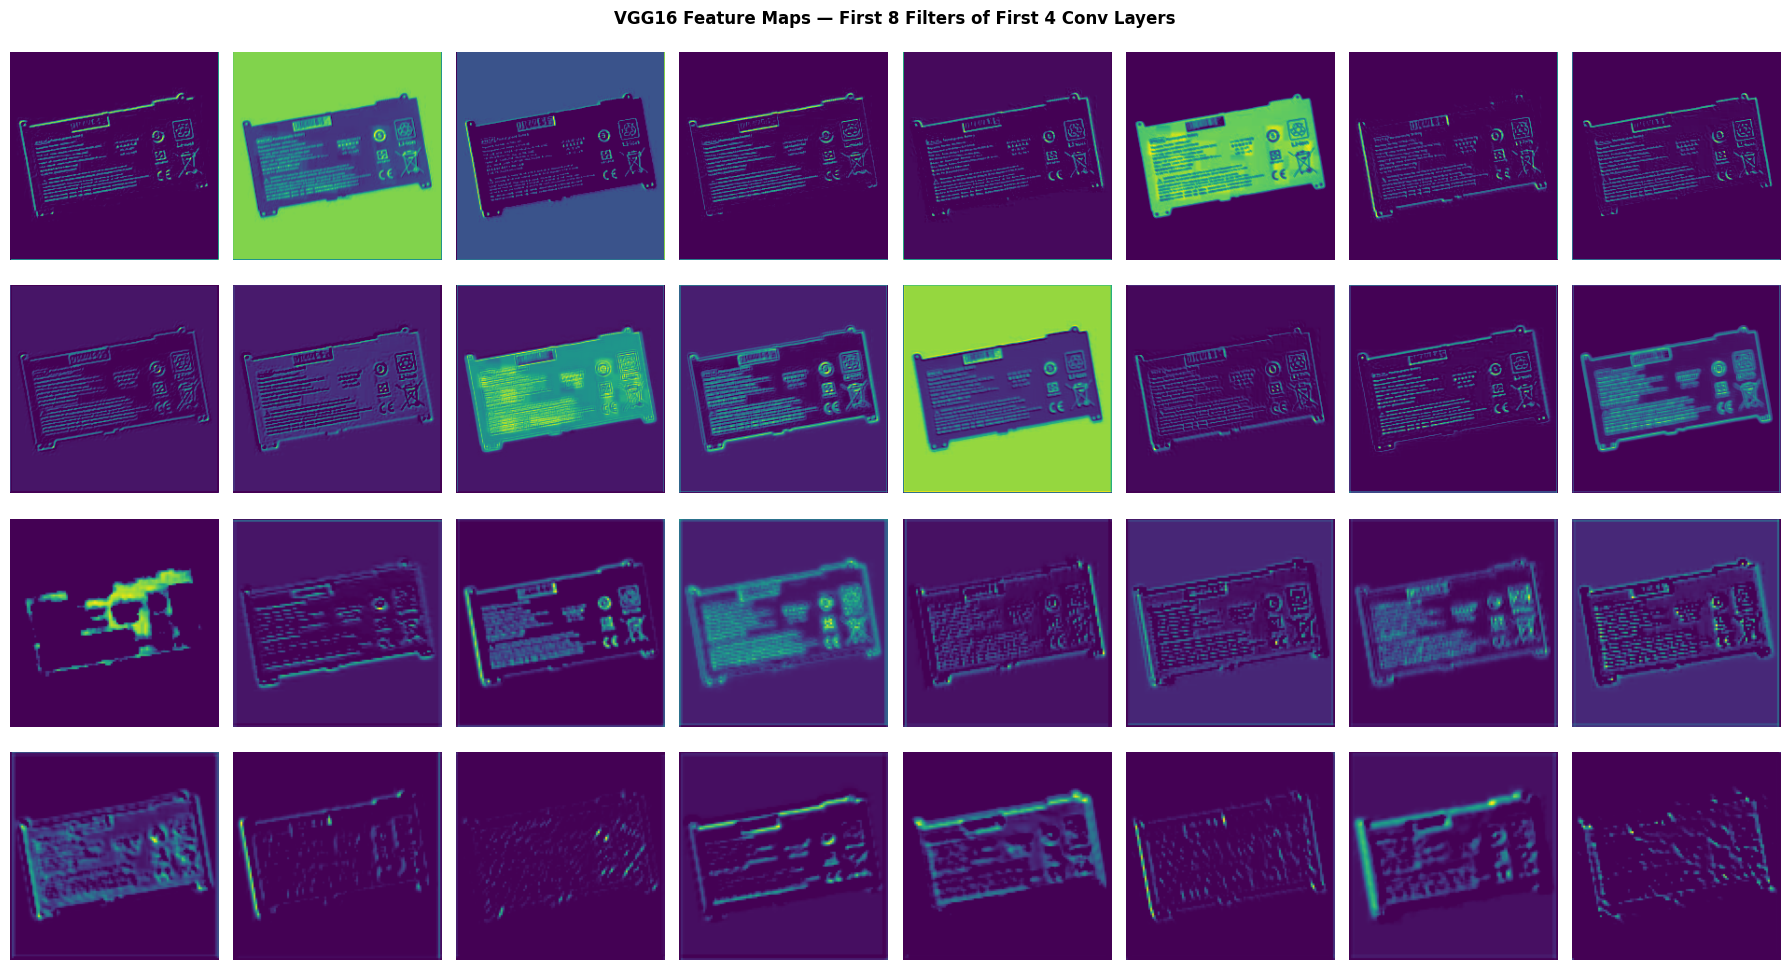

In [31]:
# B.8 VGG16 feature map visualisation
from tensorflow.keras import Model as KModel

val_gen_vgg.reset()
sample_batch, _ = next(val_gen_vgg)
sample_img = sample_batch[0:1]

conv_layer_names = [l.name for l in base_model.layers if 'conv' in l.name][:4]
feat_model = KModel(inputs=base_model.input,
                    outputs=[base_model.get_layer(n).output for n in conv_layer_names])
feat_outputs = feat_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(len(conv_layer_names), 8, figsize=(18, len(conv_layer_names) * 2.5))
for row, (fmap, name) in enumerate(zip(feat_outputs, conv_layer_names)):
    for col in range(8):
        axes[row, col].imshow(fmap[0, :, :, col], cmap='viridis')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, rotation=90, fontsize=8, labelpad=4)

plt.suptitle("VGG16 Feature Maps — First 8 Filters of First 4 Conv Layers",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("vgg16_feature_maps.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Final Comprehensive Comparison — All Models

In [32]:
# 5.1 Summary table
rows = [
    ("Baseline CNN (Adam)",        baseline_val_acc,  baseline_train_time, baseline_model.count_params()),
    ("Deeper CNN (Adam)",          deeper_val_acc,    deeper_train_time,   deeper_model.count_params()),
    ("Deeper CNN (SGD+Momentum)",  sgd_val_acc,       sgd_time,            model_sgd.count_params()),
    ("Ablation — No Dropout",      nodrop_val_acc,    nodrop_time,         model_nodrop.count_params()),
    ("VGG16 Transfer (Adam)",      vgg_val_acc,       vgg_total_time,      vgg_model.count_params()),
]

print("\n" + "=" * 72)
print(f"{'MODEL':<30} {'Val Acc':>9} {'Train Time':>12} {'Parameters':>14}")
print("=" * 72)
for name, acc, t, params in rows:
    print(f"{name:<30} {acc*100:>8.2f}%  {t/60:>10.1f}m  {params:>14,}")
print("=" * 72)


MODEL                            Val Acc   Train Time     Parameters
Baseline CNN (Adam)               73.73%        36.5m       8,523,914
Deeper CNN (Adam)                 84.89%        55.0m       9,702,186
Deeper CNN (SGD+Momentum)         68.22%        54.0m       9,702,186
Ablation — No Dropout             74.75%        23.0m       9,702,186
VGG16 Transfer (Adam)             95.02%       112.6m      15,113,290


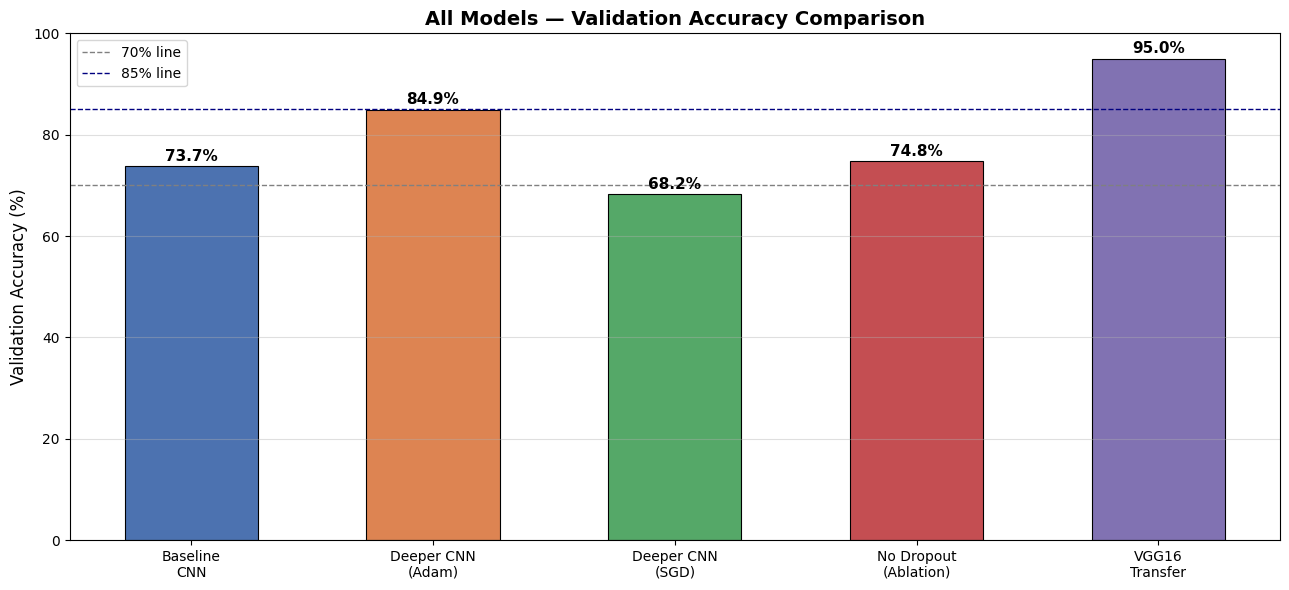


All models trained. PNG plots saved in /content/


In [33]:
# 5.2 Final comparison bar chart
names  = ['Baseline\nCNN', 'Deeper CNN\n(Adam)', 'Deeper CNN\n(SGD)',
          'No Dropout\n(Ablation)', 'VGG16\nTransfer']
accs   = [r[1]*100 for r in rows]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(names, accs, color=colors, edgecolor='black', linewidth=0.8, width=0.55)
ax.set_ylim(0, 100)
ax.axhline(70, color='gray',  linestyle='--', linewidth=1, label='70% line')
ax.axhline(85, color='navy',  linestyle='--', linewidth=1, label='85% line')
ax.set_title('All Models — Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.4)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nAll models trained. PNG plots saved in /content/")